# UK Train Rides Dataset - Exploratory Data Analysis

This notebook explores ticket sales, journey patterns, delays, revenue trends, and customer behavior.

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("railway_preprocessed.csv")

In [37]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,...,Purchase Year,Purchase Month,Purchase Month Name,Purchase Day,Has Railcard,Is Delayed,Purchase Hour,Departure Hour,Arrival Hour,Journey Duration
0,da8a6ba8-b3dc-4677-b176,2023-12-08,1900-01-01 12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,...,2023,12,December,Friday,Yes,No,12,11,13,150.0
1,b0cdd1b0-f214-4197-be53,2023-12-16,1900-01-01 11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,...,2023,12,December,Saturday,Yes,Yes,11,9,11,110.0
2,f3ba7a96-f713-40d9-9629,2023-12-19,1900-01-01 19:51:27,Online,Credit Card,No Railcard,Standard,Advance,3,Liverpool Lime Street,...,2023,12,December,Tuesday,No,No,19,18,18,30.0
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,1900-01-01 23:00:36,Station,Credit Card,No Railcard,Standard,Advance,13,London Paddington,...,2023,12,December,Wednesday,No,No,23,21,22,60.0
4,2be00b45-0762-485e-a7a3,2023-12-27,1900-01-01 18:22:56,Online,Contactless,No Railcard,Standard,Advance,76,Liverpool Lime Street,...,2023,12,December,Wednesday,No,No,18,16,19,135.0


## Dataset Overview

In [38]:
df.shape

(31653, 28)

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Transaction ID       31653 non-null  str    
 1   Date of Purchase     31653 non-null  str    
 2   Time of Purchase     31653 non-null  str    
 3   Purchase Type        31653 non-null  str    
 4   Payment Method       31653 non-null  str    
 5   Railcard             31653 non-null  str    
 6   Ticket Class         31653 non-null  str    
 7   Ticket Type          31653 non-null  str    
 8   Price                31653 non-null  int64  
 9   Departure Station    31653 non-null  str    
 10  Arrival Destination  31653 non-null  str    
 11  Date of Journey      31653 non-null  str    
 12  Departure Time       31653 non-null  str    
 13  Arrival Time         31653 non-null  str    
 14  Actual Arrival Time  29773 non-null  str    
 15  Journey Status       31653 non-null  str    
 1

In [40]:
df.describe()

,Price,Purchase Year,Purchase Month,Purchase Hour,Departure Hour,Arrival Hour,Journey Duration
count,31653.000000,31653.000000,31653.000000,31653.000000,31653.000000,31653.000000,31653.000000
mean,23.439200,2023.998926,2.489748,11.459356,11.629830,12.078571,71.154235
std,29.997628,0.032757,1.170074,6.291924,6.147796,6.267162,36.330811
min,1.000000,2023.000000,1.000000,0.000000,0.000000,0.000000,15.000000
25%,5.000000,2024.000000,1.000000,6.000000,7.000000,7.000000,30.000000
50%,11.000000,2024.000000,3.000000,11.000000,12.000000,12.000000,80.000000
75%,35.000000,2024.000000,3.000000,17.000000,17.000000,18.000000,90.000000
max,267.000000,2024.000000,12.000000,23.000000,23.000000,23.000000,270.000000


## Revenue Analysis

In [41]:
total_revenue = df["Price"].sum()

print("Total Revenue =", total_revenue)

Total Revenue = 741921


In [42]:
average_price = df["Price"].mean()

print("Average Ticket Price =", average_price)

Average Ticket Price = 23.439200075822196


In [43]:
print("Minimum Price =", df["Price"].min())
print("Maximum Price =", df["Price"].max())

Minimum Price = 1
Maximum Price = 267


In [44]:
df["Price"].describe()

count    31653.000000
mean        23.439200
std         29.997628
min          1.000000
25%          5.000000
50%         11.000000
75%         35.000000
max        267.000000
Name: Price, dtype: float64

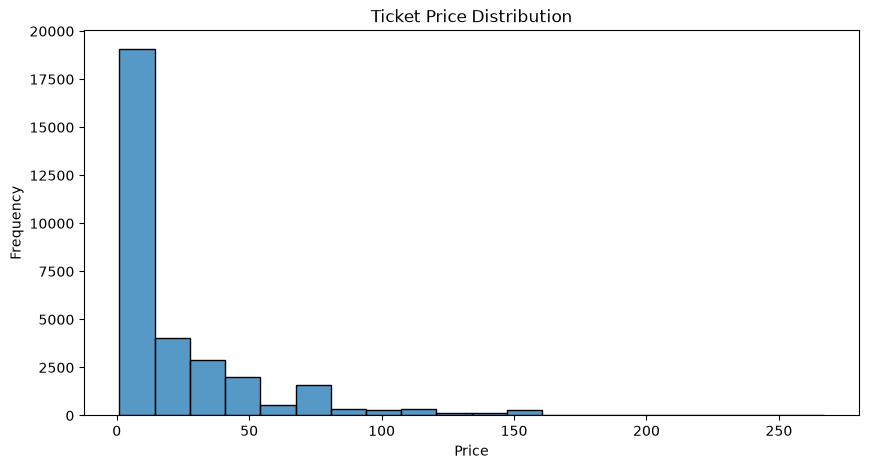

In [45]:
plt.figure(figsize=(10,5))

sns.histplot(df["Price"], bins=20)

plt.title("Ticket Price Distribution")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.show()

## Revenue Insights

- Total revenue is generated from a wide range of ticket prices.
- Most tickets are sold at relatively low prices.
- The ticket price distribution is highly right-skewed.
- A small number of expensive tickets contribute to the upper end of revenue.
- The average ticket price is higher than the median due to high-price outliers.

## Ticket Class Analysis

In [46]:
df["Ticket Class"].value_counts()

Ticket Class
Standard       28595
First Class     3058
Name: count, dtype: int64

In [47]:
df.groupby("Ticket Class")["Price"].sum()

Ticket Class
First Class    149399
Standard       592522
Name: Price, dtype: int64

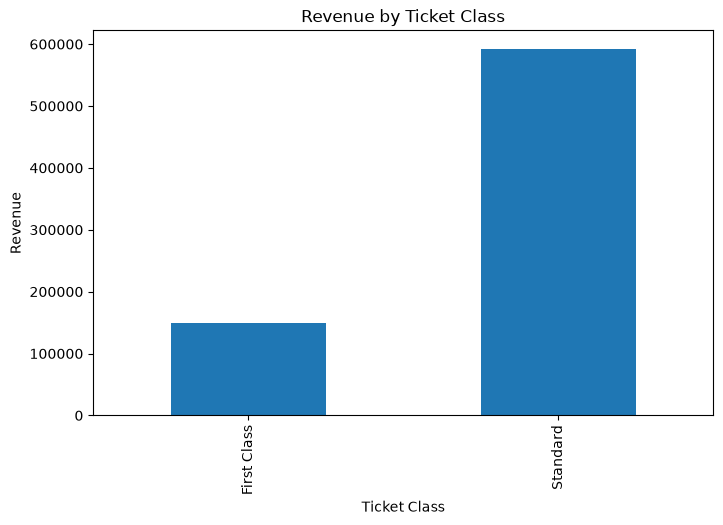

In [48]:
plt.figure(figsize=(8,5))

df.groupby("Ticket Class")["Price"].sum().plot(
    kind="bar"
)

plt.title("Revenue by Ticket Class")

plt.ylabel("Revenue")

plt.show()

In [49]:
df.groupby("Ticket Class")["Price"].mean()

Ticket Class
First Class    48.855134
Standard       20.721175
Name: Price, dtype: float64

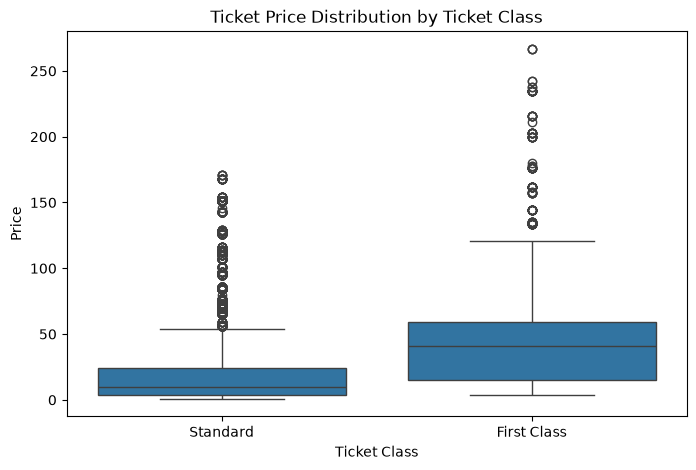

In [50]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Ticket Class",
    y="Price"
)

plt.title("Ticket Price Distribution by Ticket Class")

plt.show()

## Ticket Class Insights

- Standard tickets account for the majority of ticket sales.
- Standard Class generates the highest total revenue due to its large sales volume.
- First Class tickets have a significantly higher average price.
- First Class shows a wider price range and greater variability.
- Both ticket classes contain high-price outliers.
- Revenue is driven by volume in Standard Class and premium pricing in First Class.

## Journey Status Analysis

In [51]:
df["Journey Status"].value_counts()

Journey Status
On Time      27481
Delayed       2292
Cancelled     1880
Name: count, dtype: int64

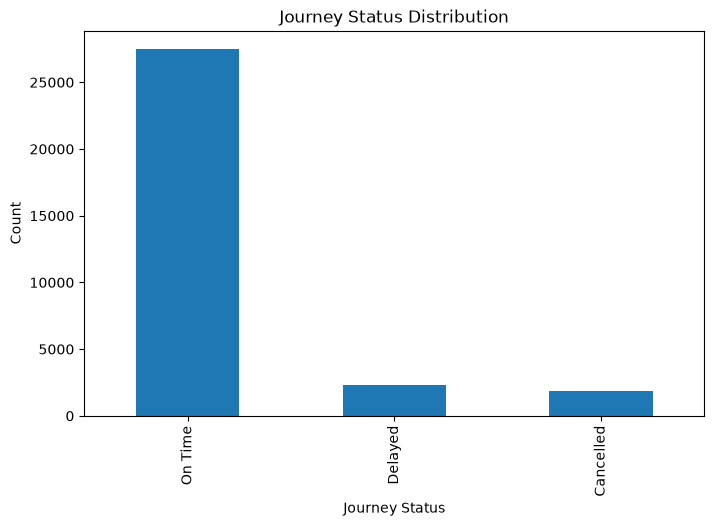

In [52]:

plt.figure(figsize=(8,5))

df["Journey Status"].value_counts().plot(
    kind="bar"
)

plt.title("Journey Status Distribution")
plt.ylabel("Count")

plt.show()

## Journey Status Insights

- Most journeys were completed on time.
- Delayed journeys represent a relatively small portion of total trips.
- Cancelled journeys account for a small percentage of all journeys.
- The railway service demonstrates a high level of operational reliability.
- On-time performance is the dominant journey outcome.

## Delay Reason Analysis

In [53]:
df["Reason for Delay"].value_counts()

Reason for Delay
Weather               995
Technical Issue       707
Signal Failure        523
Signal failure        447
Staffing              410
Staff Shortage        399
Weather Conditions    377
Traffic               314
Name: count, dtype: int64

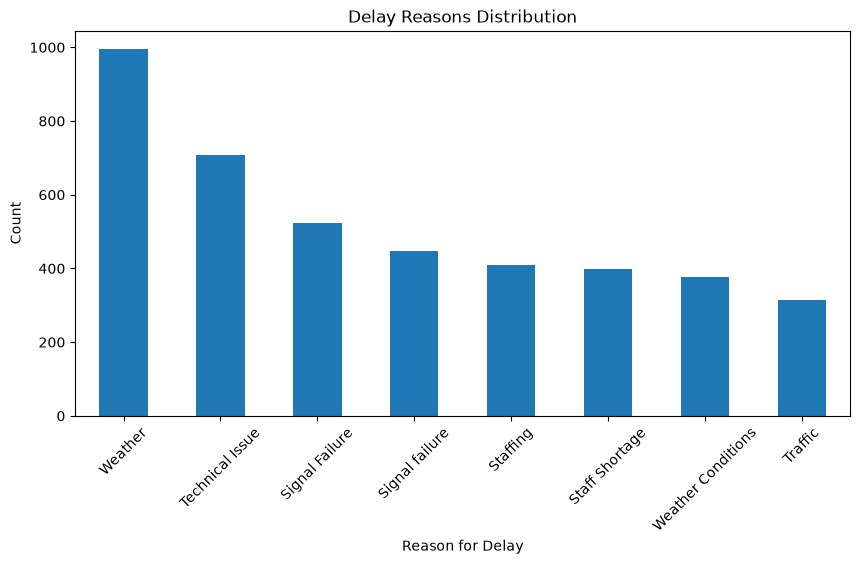

In [54]:
plt.figure(figsize=(10,5))

df["Reason for Delay"].value_counts().plot(
    kind="bar"
)

plt.title("Delay Reasons Distribution")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

## Delay Reason Insights

- Weather-related issues are the leading cause of train delays.
- Technical issues are the second most common delay factor.
- Signal-related failures contribute significantly to service disruptions.
- Staffing and staff shortages also affect operational performance.
- Traffic is the least common recorded delay reason.
- Some delay categories appear duplicated due to inconsistent naming (e.g., Weather vs Weather Conditions, Signal Failure vs Signal failure).

In [55]:
df["Reason for Delay"] = df["Reason for Delay"].replace({
    "Weather Conditions": "Weather",
    "Signal failure": "Signal Failure",
    "Staffing": "Staff Shortage"
})

In [56]:
df["Reason for Delay"].value_counts()

Reason for Delay
Weather            1372
Signal Failure      970
Staff Shortage      809
Technical Issue     707
Traffic             314
Name: count, dtype: int64

## Purchase Type Revenue Analysis

In [57]:
df.groupby("Purchase Type")["Price"].sum()

Purchase Type
Online     382754
Station    359167
Name: Price, dtype: int64

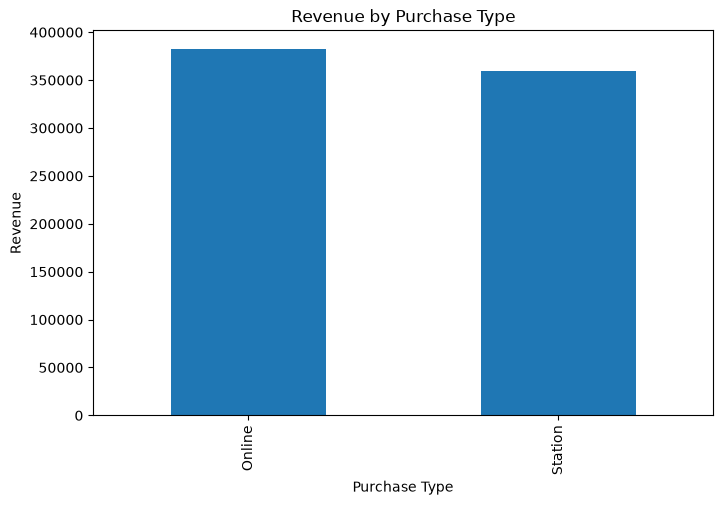

In [58]:
plt.figure(figsize=(8,5))

df.groupby("Purchase Type")["Price"].sum().plot(
    kind="bar"
)

plt.title("Revenue by Purchase Type")
plt.ylabel("Revenue")

plt.show()

## Purchase Type Revenue Insights

- Online purchases generate slightly higher revenue than station purchases.
- Both purchase channels contribute significantly to total revenue.
- Customers show strong adoption of online ticket purchasing.
- Revenue distribution between the two channels is relatively balanced.
- Online sales provide a small revenue advantage over station sales.

## Monthly Revenue Analysis

In [59]:
monthly_revenue = df.groupby(
    ["Purchase Month", "Purchase Month Name"]
)["Price"].sum().reset_index()

monthly_revenue = monthly_revenue.sort_values(
    "Purchase Month"
)

monthly_revenue

,Purchase Month,Purchase Month Name,Price
0,1,January,205091
1,2,February,154118
2,3,March,194789
3,4,April,187231
4,12,December,692


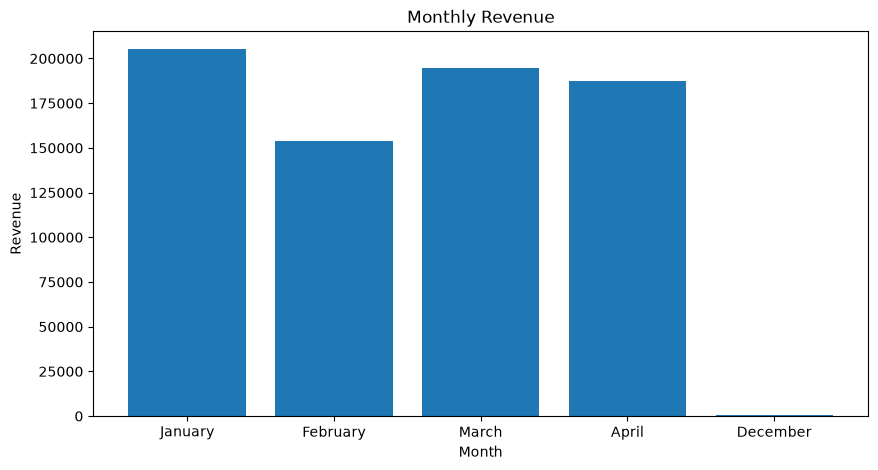

In [60]:
plt.figure(figsize=(10,5))

plt.bar(
    monthly_revenue["Purchase Month Name"],
    monthly_revenue["Price"]
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

## Monthly Revenue Insights

- January generated the highest revenue among all recorded months.
- March and April also produced strong revenue performance.
- February generated lower revenue compared to January, March, and April.
- December contains very limited data and should not be used for trend analysis.
- Revenue fluctuates across months, indicating possible seasonal demand patterns.

## Route Revenue Analysis

In [61]:
df["Route"] = (
    df["Departure Station"]
    + " → "
    + df["Arrival Destination"]
)

df["Route"].head()

0        London Paddington → Liverpool Lime Street
1                        London Kings Cross → York
2    Liverpool Lime Street → Manchester Piccadilly
3                      London Paddington → Reading
4            Liverpool Lime Street → London Euston
Name: Route, dtype: str

In [62]:
route_revenue = (
    df.groupby("Route")["Price"]
      .sum()
      .sort_values(ascending=False)
)

route_revenue.head(10)

Route
London Kings Cross → York                        183193
Liverpool Lime Street → London Euston            113299
London Paddington → Reading                       65368
London Euston → Manchester Piccadilly             61004
London St Pancras → Birmingham New Street         52869
London Euston → Birmingham New Street             50349
Manchester Piccadilly → London Euston             33860
Birmingham New Street → London St Pancras         19011
Manchester Piccadilly → Liverpool Lime Street     17310
Manchester Piccadilly → London Paddington         16432
Name: Price, dtype: int64

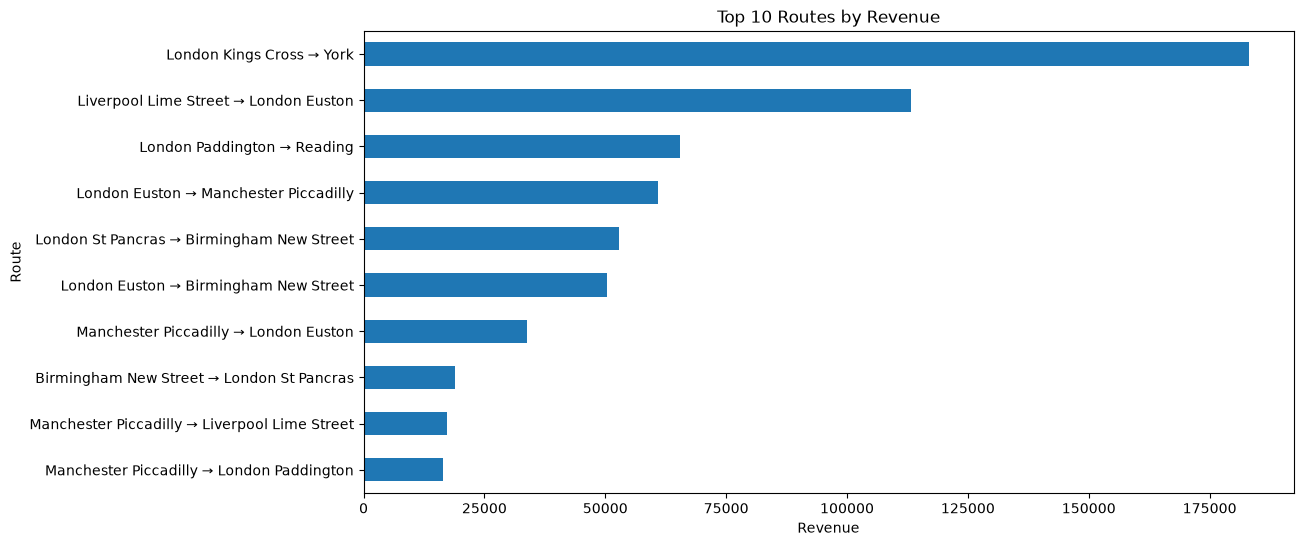

In [63]:
plt.figure(figsize=(12,6))

route_revenue.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Routes by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Route")

plt.show()

## Route Revenue Insights

- London Kings Cross → York is the highest revenue-generating route.
- Liverpool Lime Street → London Euston ranks second in total revenue.
- Revenue is concentrated among a small number of major routes.
- Intercity routes generate substantially more revenue than others.
- The top routes represent key travel corridors in the network.

## Delay Impact on Revenue

In [64]:
df.groupby("Journey Status")["Price"].sum()

Journey Status
Cancelled     45456
Delayed      126814
On Time      569651
Name: Price, dtype: int64

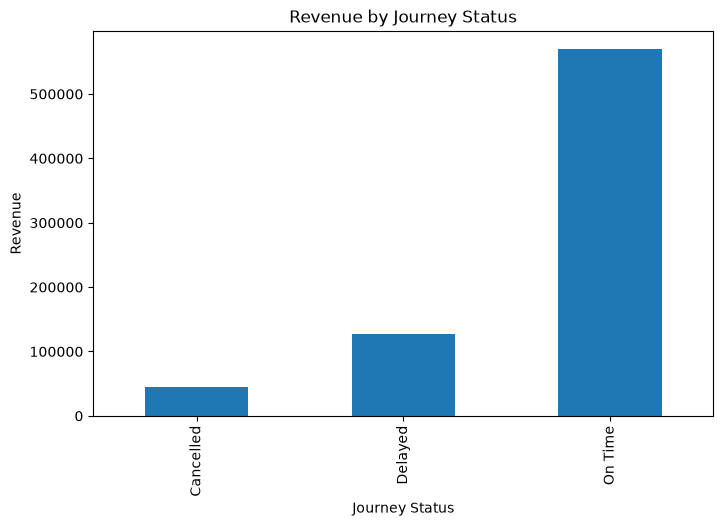

In [65]:
plt.figure(figsize=(8,5))

df.groupby("Journey Status")["Price"].sum().plot(
    kind="bar"
)

plt.title("Revenue by Journey Status")
plt.xlabel("Journey Status")
plt.ylabel("Revenue")

plt.show()

## Delay Impact Insights

- On-time journeys generate the highest total revenue.
- Delayed journeys contribute a significant portion of revenue despite being fewer in number.
- Cancelled journeys generate the lowest revenue.
- Service reliability appears closely linked to revenue generation.
- Improving punctuality could help maintain customer satisfaction and revenue performance.

## Most Delayed Routes

In [66]:
delayed_routes = (
    df[df["Journey Status"] == "Delayed"]
    .groupby("Route")
    .size()
    .sort_values(ascending=False)
)

delayed_routes.head(10)

Route
Liverpool Lime Street → London Euston            780
Manchester Piccadilly → Liverpool Lime Street    354
London Euston → Birmingham New Street            242
Manchester Piccadilly → London Euston            240
London Kings Cross → York                        131
Liverpool Lime Street → Manchester Piccadilly    107
Birmingham New Street → Manchester Piccadilly     96
London Paddington → Reading                       66
Manchester Piccadilly → Leeds                     64
Edinburgh Waverley → London Kings Cross           51
dtype: int64

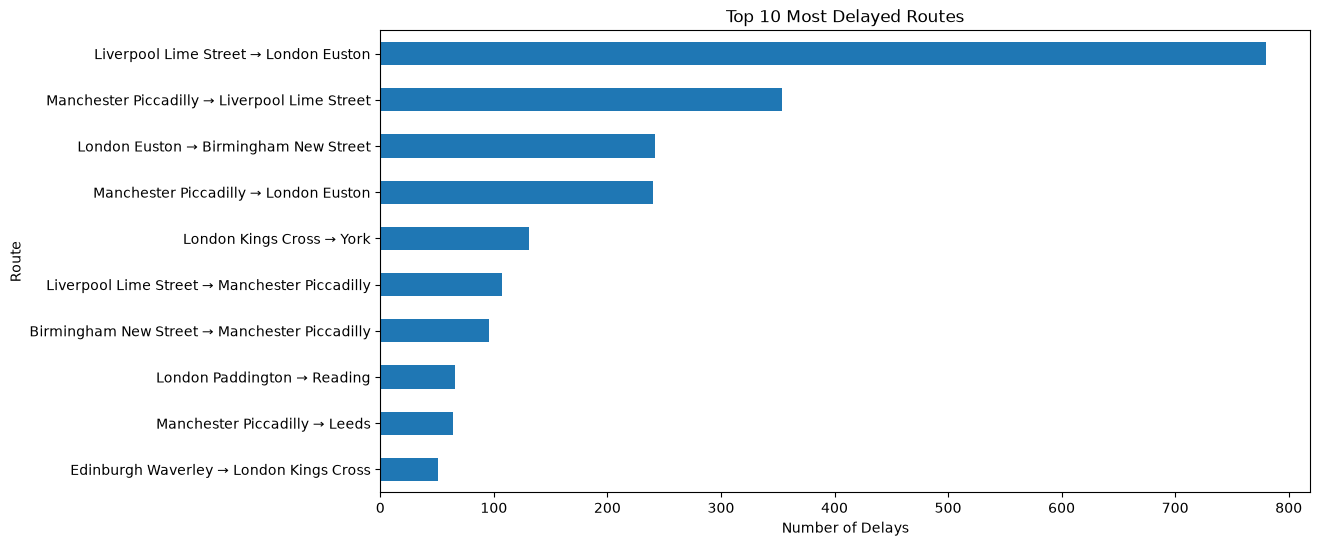

In [67]:
plt.figure(figsize=(12,6))

delayed_routes.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Most Delayed Routes")
plt.xlabel("Number of Delays")
plt.ylabel("Route")

plt.show()

## Most Delayed Routes Insights

- Liverpool Lime Street → London Euston experiences the highest number of delays.
- Manchester Piccadilly and London Euston appear frequently among delayed routes.
- Delays are concentrated on a small group of major routes.
- High-traffic routes tend to experience more operational disruptions.
- Monitoring these routes could help improve overall network performance.